<a href="https://colab.research.google.com/github/lp74428-crypto/Talleres_DataScience_Laura_Perez/blob/main/TALLER_PR%C3%81CTICO_%E2%80%93_MACHINE_LEARNING_Laura_Perez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Entrega: 08 de julio

Clasificación vs Regresión (Elección del modelo)
Objetivo del taller
Aplicar un flujo básico de Machine Learning para resolver un problema real, identificando correctamente si se trata de regresión o clasificación, construyendo un modelo predictivo y evaluando su desempeño.


INSTRUCCIONES DEL TALLER

Parte 1 – Comprensión del problema

    
Identifica la variable objetivo (target)
Responde:

  ○ ¿Es un problema de clasificación o regresión?
  ¿Por qué?
  
Describe brevemente el contexto del problema

El data set seleccionado requiere predecir si una solicitud de crédito será aprobada o no, lo que indica que es un problema de Clasificación binaria, pues la respuesta a entregar será Aprobada o no aprobada. El resultado no será un número continuo.

  

Parte 2 – Exploración de datos (EDA básica)

    • Revisar valores nulos
    • Identificar variables numéricas y categóricas
    • Detectar la variable objetivo
    • Mostrar al menos:
        ○ 2 gráficos (ej: distribución, conteos o correlación)

In [1]:
#Librerias:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [ ]:
#Carga exploración de datos

https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset

In [9]:
url_train = 'https://raw.githubusercontent.com/subashgandyer/datasets/master/loan_train.csv'
url_test = 'https://raw.githubusercontent.com/subashgandyer/datasets/master/loan_test.csv'

df_train = pd.read_csv(url_train)
df_test = pd.read_csv(url_test)

print()
df_train.head()



,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [12]:
#• Identificar variables numéricas y categóricas

print("\nInformación del dataset:")
df_train.info()

print("\nDistribución de la variable objetivo:")
print(df_train['Loan_Status'].value_counts())
#Estado del préstamo (Aprobado: Y / No aprobado: N).

#Variables numéricas: applicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term
#Variables categóricas: Loan_ID, Gender, Married, Depents, Education, Self_Employed, Property_Area, Loan_Status.


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

Distribución de la variable objetivo:
Loan_Status
Y    422
N    192
Name: count, dtyp

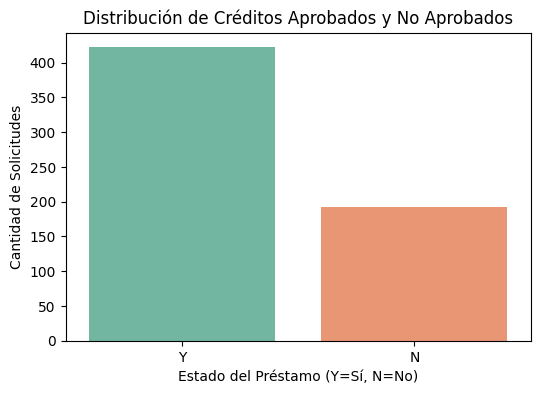

In [19]:
# GRAFICO DE DISTRIBUCIÓN

plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df_train, hue='Loan_Status', palette='Set2', legend=False)
plt.title('Distribución de Créditos Aprobados y No Aprobados')
plt.xlabel('Estado del Préstamo (Y=Sí, N=No)')
plt.ylabel('Cantidad de Solicitudes')
plt.show()

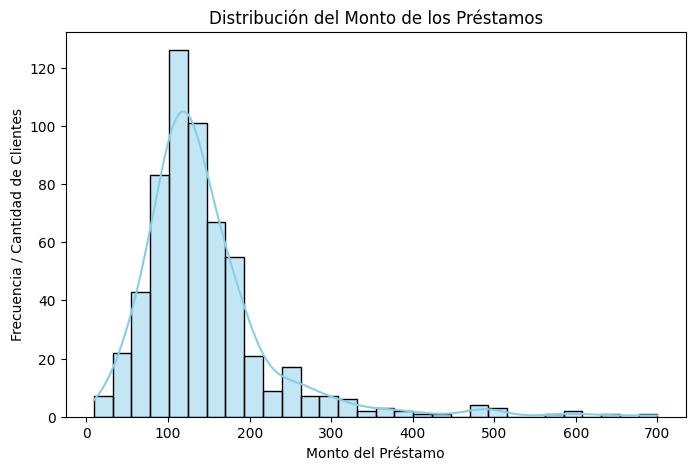

In [21]:
plt.figure(figsize=(8, 5))
# kde=True añade la curva suave que muestra el comportamiento de la distribución
sns.histplot(data=df_train, x='LoanAmount', kde=True, color='skyblue', bins=30)

plt.title('Distribución del Monto de los Préstamos')
plt.xlabel('Monto del Préstamo')
plt.ylabel('Frecuencia / Cantidad de Clientes')
plt.show()


#La gran mayoría de los clientes pide préstamos de bajo monto, pocos clientes piden montos extremadamente altos.

Parte 3 – Preparación de datos

    • Manejo de valores faltantes
    • Codificación de variables categóricas
    • Separación en:

        ○ X (variables predictoras)
        ○ y (variable objetivo)
        
    • División entrenamiento / prueba (80/20 o 70/30)

In [24]:
#MANEJO DE VALORES FALTANTES

#Variables categóricas con datos faltantes
categoricas_faltantes = ['Gender', 'Married', 'Dependents', 'Self_Employed']

for columna in categoricas_faltantes:
    moda = df_train[columna].mode()[0]
    df_train[columna] = df_train[columna].fillna(moda)

mediana_monto = df_train['LoanAmount'].median()
df_train['LoanAmount'] = df_train['LoanAmount'].fillna(mediana_monto)

mediana_plazo = df_train['LoanAmount_Term'].median() if 'LoanAmount_Term' in df_train.columns else df_train['Loan_Amount_Term'].median()
df_train['Loan_Amount_Term'] = df_train['Loan_Amount_Term'].fillna(mediana_plazo)

moda_historial = df_train['Credit_History'].mode()[0]
df_train['Credit_History'] = df_train['Credit_History'].fillna(moda_historial)

print(df_train.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [25]:
#CODIFICACIÓN DE VARIABLES CATEGORICAS

# Mapas de conversión manual
df_train['Gender'] = df_train['Gender'].map({'Male': 1, 'Female': 0})
df_train['Married'] = df_train['Married'].map({'Yes': 1, 'No': 0})
df_train['Education'] = df_train['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df_train['Self_Employed'] = df_train['Self_Employed'].map({'Yes': 1, 'No': 0})

#  "+" pasándolo a número
df_train['Dependents'] = df_train['Dependents'].replace('3+', 3).astype(int)

# Codificación dd la variable objetivo (Y = 1, N = 0)
df_train['Loan_Status'] = df_train['Loan_Status'].map({'Y': 1, 'N': 0})

# Aplicar One-Hot Encoding a la columna Property_Area
df_train = pd.get_dummies(df_train, columns=['Property_Area'], drop_first=True, dtype=int)

# Eliminar la columna de ID  no aporta información
if 'Loan_ID' in df_train.columns:
    df_train = df_train.drop(columns=['Loan_ID'])

df_train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,0,1
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,0,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,0,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,0,1


In [26]:
#Separación en: X (variables predictoras), y (variable objetivo)

# 1. Creación X
X = df_train.drop(columns=['Loan_Status'])

# 2. Creación y
y = df_train['Loan_Status']

# 3. Verificación de  dimensiones
print(f"📐 Tamaño de las variables predictoras (X): {X.shape}")
print(f"🎯 Tamaño de la variable objetivo (y): {y.shape}")

📐 Tamaño de las variables predictoras (X): (614, 12)
🎯 Tamaño de la variable objetivo (y): (614,)


In [28]:
#División entrenamiento / prueba (80/20 o 70/30)

# Divicion de los datos en entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# tamaños de los sets de datos
print(f" Total de datos originales: {X.shape[0]}")
print(f" Datos para Entrenar (X_train): {X_train.shape[0]} solicitudes")
print(f" Datos para Probar (X_test): {X_test.shape[0]} solicitudes")


 Total de datos originales: 614
 Datos para Entrenar (X_train): 491 solicitudes
 Datos para Probar (X_test): 123 solicitudes


In [ ]:
Parte 4 – Modelado


• Entrenar al menos 2 modelos

In [31]:
# 1. MODELO 1: Regresión Logística (Subimos a 5000 iteraciones)

modelo_logistico = LogisticRegression(max_iter=5000, random_state=42)
modelo_logistico.fit(X_train, y_train)
predicciones_logistica = modelo_logistico.predict(X_test)

# 2. MODELO 2: Árbol de Decisión
modelo_arbol = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arbol.fit(X_train, y_train)
predicciones_arbol = modelo_arbol.predict(X_test)

print("¡modelos entrenados a la perfección")

¡modelos entrenados a la perfección


📊 --- MÉTRICAS PARA: Regresión Logística ---
• Accuracy (Exactitud): 0.86
• Precision (Precisión): 0.84
• Recall (Sensibilidad): 0.99
• F1-Score: 0.91

📊 --- MÉTRICAS PARA: Árbol de Decisión ---
• Accuracy (Exactitud): 0.83
• Precision (Precisión): 0.83
• Recall (Sensibilidad): 0.95
• F1-Score: 0.89



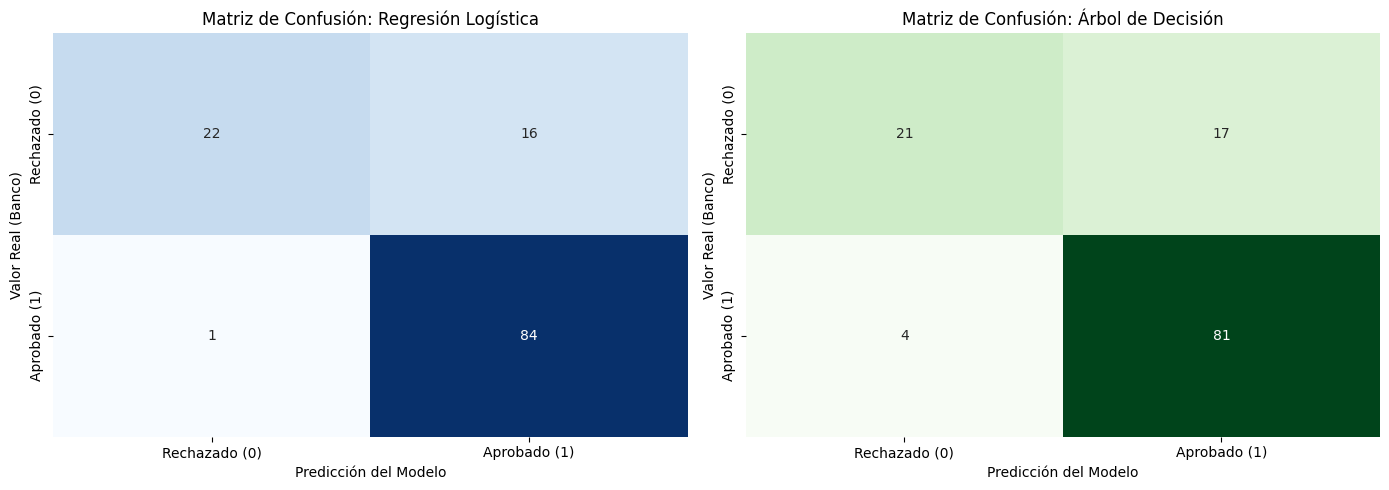

<Figure size 640x480 with 0 Axes>

In [33]:

def evaluar_modelo(nombre_modelo, y_real, y_pred):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
  print(f"📊 --- MÉTRICAS PARA: {nombre_modelo} ---")
  print(f"• Accuracy (Exactitud): {accuracy_score(y_real, y_pred):.2f}")
  print(f"• Precision (Precisión): {precision_score(y_real, y_pred):.2f}")
  print(f"• Recall (Sensibilidad): {recall_score(y_real, y_pred):.2f}")
  print(f"• F1-Score: {f1_score(y_real, y_pred):.2f}\n")

evaluar_modelo("Regresión Logística", y_test, predicciones_logistica)
evaluar_modelo("Árbol de Decisión", y_test, predicciones_arbol)

# 2. GRAFICAR LAS MATRICES DE CONFUSIÓN
from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz Regresión Logística
cm_log = confusion_matrix(y_test, predicciones_logistica)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Matriz de Confusión: Regresión Logística')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Valor Real (Banco)')
axes[0].set_xticklabels(['Rechazado (0)', 'Aprobado (1)'])
axes[0].set_yticklabels(['Rechazado (0)', 'Aprobado (1)'])

# Matriz Árbol de Decisión
cm_tree = confusion_matrix(y_test, predicciones_arbol)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Matriz de Confusión: Árbol de Decisión')
axes[1].set_xlabel('Predicción del Modelo')
axes[1].set_ylabel('Valor Real (Banco)')
axes[1].set_xticklabels(['Rechazado (0)', 'Aprobado (1)'])
axes[1].set_yticklabels(['Rechazado (0)', 'Aprobado (1)'])

plt.tight_layout()
plt.show()

# Matriz Árbol de Decisión
cm_tree = confusion_matrix(y_test, predicciones_arbol)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Matriz de Confusión: Árbol de Decisión')
axes[1].set_xlabel('Predicción del Modelo')
axes[1].set_ylabel('Valor Real (Banco)')
axes[1].set_xticklabels(['Rechazado (0)', 'Aprobado (1)'])
axes[1].set_yticklabels(['Rechazado (0)', 'Aprobado (1)'])

plt.tight_layout()
plt.show()

Parte 6 - Interpretación

¿Qué tan bueno es el modelo?

El modelo es muy bueno y confiable. Tuvo un 86% de acierto  en los datos de prueba, lo que significa que predice correctamente la aprobación o rechazo en 86 de cada 100 casos.

¿Qué variable parece influir más en la predicción?
El historial crediticio, si el cliente tiene un buen historial, sus posibilidades de aprobacion son altas.

¿Qué mejorarías si tuvieras más tiempo?
Probaria oreos modelos.
